In [1]:
import numpy as np
np.set_printoptions(threshold = np.inf)
import re
import openpnm as op
import heapq as hq
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import scipy.sparse as sprs
from scipy.sparse import csgraph
from scipy.sparse.csgraph import connected_components
from openpnm._skgraph.simulations import bond_percolation, site_percolation
import os
current_directory = os.getcwd()
print(current_directory)

/home/gladys/Documents/Jupyter_projects/NewOpenPNM/Report_2024_final


In [2]:
ws=op.Workspace()
proj = ws.new_project()

In [3]:
np.random.seed(10)
pn = op.network.Cubic(shape=[25,25,1],spacing=1.e-6)
#pn = op.network.Cubic(shape=[10,10,1],spacing=1.e-3)
pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)
pn.regenerate_models()

In [4]:
incidence_m = pn.network.create_incidence_matrix(fmt='csr')

In [5]:
Inlets = pn.pores('left')
Outlets = pn.pores('right')
P_inside = np.setdiff1d(pn.pores(),Outlets)
pn['pore.volume'][Inlets] = 0.0

In [6]:
ax = op.visualization.plot_coordinates(pn, size_by=(pn['pore.diameter']*1e20),markersize=20)
ax = op.visualization.plot_connections(pn, ax=ax, size_by=(pn['throat.diameter']*1e20), linewidth=2)
plt.savefig(f"2D_25x25_Hys/Network_25x25.png")
plt.close()  

# Set Phases CO2-Water

In [7]:
CO2 = op.phase.Phase(network=pn,name='CO2')
CO2['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
CO2['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
CO2['pore.surface_tension'] = 0.035
CO2['pore.contact_angle'] = 150
CO2['pore.density'] = 850
CO2['throat.density'] = 850
CO2['pore.viscosity'] = 4.758262054201777e-05
CO2['throat.viscosity'] = 4.758262054201777e-05
CO2['pore.pressure'] = 8273709.0
CO2['throat.value_p0'] = 8273709.0
CO2['pore.value_p0'] = 8273709.0
#
# CO2 viscosity - Reference correlation for the viscosity of CO2
# linear fit up to 300 K at 8273709.0 Pa around 1200 psi
value_p0 = 8273709.0 #CO2['pore.pressure'][0]
#
model = op.models.physics.capillary_pressure.washburn
CO2.add_model(propname='throat.entry_pressure',
               model = model)
model1 = op.models.physics.hydraulic_conductance.hagen_poiseuille
CO2.add_model(propname='throat.hydraulic_conductance',
              model=model1) 
CO2.regenerate_models()
#print('Esta throat conduit hydraulic conductance?',CO2['throat.hydraulic_conductance'])

In [8]:
print(CO2['pore.viscosity'][0])

4.758262054201777e-05


In [9]:
water = op.phase.Phase(network=pn,name='water')
water['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
water['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
water['pore.surface_tension'] = 0.035
water['pore.contact_angle'] = 30
water['pore.viscosity'] = 1.05e-3
water['throat.viscosity'] = 1.05e-3
water['pore.density'] = 996.95
water['throat.density'] = 996.95
water['pore.pressure'] = 101325.0
water['throat.value_p0'] = 101325.0
water['pore.value_p0'] = 101325.0
water.add_model(propname='throat.entry_pressure',
                model = model)
water.add_model(propname='throat.hydraulic_conductance',
                model=model1) 
#water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()
print(water['pore.pressure'][0] )

101325.0


In [10]:
def bfs_from_initial_pore(initial_pore, throats, conns, incidence_matrix, outlet_pores, throat_mask, pore_mask):
    """
    Performs BFS to find possible paths from the initial_pore to any outlet pore,
    starting from specified throats.

    Parameters:
    - initial_pore (int): The index of the initial pore.
    - throats (list): List of throat indices to start the BFS from.
    - conns (np.ndarray): Array of connected pores for each throat (shape: [n_throats, 2]).
    - incidence_matrix (csr_matrix): Incidence matrix between pores and throats.
    - outlet_pores (list or np.ndarray): Indices of outlet pores.
    - throat_mask (np.ndarray): Boolean array indicating active throats (True if active).
    - pore_mask (np.ndarray): Boolean array indicating active pores (True if active).

    Returns:
    - list: The shortest valid path as a list of throat indices, or an empty list if no path is found.
    """

    # Filter the provided throats based on the throat_mask
    throats_to_explore = [throat for throat in throats if throat_mask[throat]]
    # print('Throats to start BFS from:', throats_to_explore)

    # Initialize the BFS queue with specified throats
    queue = deque()
    for throat in throats_to_explore:
        # Start paths from the initial_pore via each specified throat
        queue.append((throat, [throat], set([initial_pore])))

    visited_throats = set()
    valid_paths = []

    while queue:
        current_throat, path, visited_pores_in_path = queue.popleft()

        if current_throat in visited_throats:
            continue  # Skip if already visited
        visited_throats.add(current_throat)

        # Get the pores connected by the current throat
        connected_pores = conns[current_throat]

        # Exclude already visited pores
        next_pores = [pore for pore in connected_pores if pore not in visited_pores_in_path and pore_mask[pore]]

        for pore in next_pores:
            new_visited_pores = visited_pores_in_path.union([pore])

            # Check if the pore is an outlet pore
            if np.isin(pore,outlet_pores):
                valid_paths.append(path)
                continue  # Found a path to an outlet pore

            # Get neighboring throats from the current pore
            neighbor_throats = incidence_matrix[pore, :].nonzero()[1]
            neighbor_throats = [t for t in neighbor_throats if throat_mask[t] and t not in visited_throats]

            for next_throat in neighbor_throats:
                # Avoid cycles by not revisiting throats
                queue.append((next_throat, path + [next_throat], new_visited_pores))

    # Return the shortest valid path if any are found
    if valid_paths:
        #shortest_path = min(valid_paths, key=len)
        #print('Shortest valid path found:', shortest_path)
        return valid_paths
    else:
        #print('No valid path found from pore', initial_pore, 'to outlet pores.')
        return []  # No valid path found

# Absolute Permeability with CO2 before Drainage

In [11]:
# BD_flow_CO2 = op.algorithms.StokesFlow(network=pn, phase=CO2)
# BD_flow_CO2.set_value_BC(pores=Inlets, values=1)
# BD_flow_CO2.set_value_BC(pores=Outlets, values=0)
# BD_flow_CO2.run()
# Inlet_flow_BD_CO2 = np.absolute(BD_flow_CO2.rate(pores=Inlets))
# print(Inlet_flow_BD_CO2)
# print(BD_flow_CO2['pore.pressure'][Inlets])
# print(BD_flow_CO2.rate(pores=Inlets, mode='single'))
# print(np.max(CO2['throat.hydraulic_conductance']))

In [12]:
# BD_flow_water = op.algorithms.StokesFlow(network=pn, phase=water)
# BD_flow_water.set_value_BC(pores=Inlets, values=1)
# BD_flow_water.set_value_BC(pores=Outlets, values=0)
# BD_flow_water.run()
# Inlet_flow_BD_water = np.absolute(BD_flow_water.rate(pores=Inlets))
# print(Inlet_flow_BD_water)
# print(BD_flow_water['pore.pressure'][Inlets])
# print(BD_flow_water.rate(pores=Inlets, mode='single'))
# print(np.max(water['throat.hydraulic_conductance']))

# Drainage - CO2 Invasion

In [13]:
Max_seq =1e4
ip = {}
ip['throat.invasion_pressure'] = np.zeros(pn.Nt, dtype=float)
ip['pore.invasion_pressure'] = np.zeros(pn.Np, dtype=float)
ip['throat.invasion_sequence'] = np.full(pn.Nt,Max_seq,dtype=int)
ip['pore.invasion_sequence'] = np.full(pn.Np,Max_seq,dtype=int)

In [14]:
Pinv = np.zeros(pn.Np, dtype=bool)  # Pre-allocate array for storing pore invasion state
Tinv = np.zeros(pn.Nt, dtype=bool)  # Pre-allocate array for storing throat invasion state

In [15]:
Pinv[Inlets] = True

In [16]:
Ts1 = pn.find_neighbor_throats(pores=Inlets, mode='xor', asmask=False)
# print(Ts1)
Ts2 = pn.find_neighbor_throats(pores=Outlets, mode='xor', asmask=False)
# print(Ts2)

In [17]:
# list of the throats linked to the Inlet pores that are candidates to be invided
q = [(CO2['throat.entry_pressure'][i], i ) for i in Ts1]
#Sort for the minimum  Capillary pressure of the throats that candidates to be invaded
hq.heapify(q)
#print(q)

In [18]:
low = 1.0 * CO2['throat.entry_pressure'].min()
hi = 1.0 * CO2['throat.entry_pressure'].max()
print(low,hi)
Global_T_entry_p = np.logspace(np.log10(low),np.log10(hi), 25)
# print(Global_T_entry_p)
#Global_T_entry_p = np.unique([item[0] for item in q])
print(Global_T_entry_p)

355720.5091724178 1207125.273034352
[ 355720.50917242  374299.32895381  393848.49634116  414418.69132856
  436063.24086029  458838.2570776   482802.78278595  508018.94451978
  534552.11360166  562471.07561336  591848.20871815  622759.67129672
  655285.59938295  689510.31441161  725522.54181639  763415.64104506
  803287.84758796  845242.52764742  889388.44610813  935840.04850332
  984717.75770766 1036148.28612601 1090264.96418743 1147208.08599598
 1207125.27303435]


In [19]:
# Global_T_entry_p = [ 59.81782701,  61.36009656,  62.94213009,  64.56495284,  66.22961647,
#   67.93719974,  69.68880925,  71.4855801,   73.3286767,   75.21929344,
#   77.15865553,  79.14801975,  81.1886753,   83.28194461,  85.42918422,
#   87.63178562,  89.89117619,  92.20882012,  94.58621934,  97.02491452,
#   99.52648601, 102.09255497, 104.7247843,  107.4248798,  110.19459126,
#  113.03571357, 115.95008789, 118.93960287, 122.00619584, 125.15185408,
#  128.37861612, 131.68857304,  132.0,  133.0, 135.0, 136.0, 137.0, 138.5667068, 139.0,140.0, 141.0,142.13934096,
#  145.80408755, 149.56332147, 153.41947887, 157.37505871, 161.43262437,
#  165.59480533, 169.86429887, 174.24387179, 178.73636226, 183.34468159,
#  188.07181619, 192.92082943, 197.89486368, 202.99714234, 208.2309719 ]

In [20]:
counter = 0
counter_press = 0
ip['pore.invasion_sequence'][Pinv] = counter
ip['throat.invasion_sequence'][Tinv] = counter 

In [21]:
#Loop over pressures
for pressure in Global_T_entry_p:
    try:
        # print("Pressure",pressure)
        counter_press += 1
        int_pore_queue = list(P_inside)
        
        ip['pore.invasion_sequence'][Inlets] = 0

        pressure_check = np.any(CO2['throat.entry_pressure'][i] <= pressure for i in Ts1)
        
        if not pressure_check:
            # print('Not throat to be invaded at pressure',pressure)
            continue
    
        while len(int_pore_queue) > 0 :
            try:
                pore_index = hq.heappop(int_pore_queue)
                # Find neighboring throats of the current pore
                neighbor_throats = incidence_m[pore_index].nonzero()[1]
                # print('Neigh_throats',neighbor_throats)               
                can_invade = [(CO2['throat.entry_pressure'][i],i) 
                              for i in neighbor_throats 
                              if CO2['throat.entry_pressure'][i]<=pressure and Pinv[pore_index]]
                              
                if not can_invade:
                    # print('O poro', pore_index,'nao tem nenhuma garganta para invadir',can_invade)
                    continue
                
                throat_indices = [thr_indx for pres, thr_indx in can_invade]
                #throat_indices = np.array([thr_indx for pres, thr_indx in can_invade], dtype=int)
                                
                valid_paths = bfs_from_initial_pore(initial_pore=pore_index,
                                                    throats = throat_indices,
                                                    conns = pn.conns,
                                                    incidence_matrix=incidence_m,
                                                    outlet_pores=Outlets,
                                                    throat_mask=~Tinv,
                                                    pore_mask=~Pinv)
                
                if not valid_paths:
                    # print('O poro', pore_index,'nao tem valid path from BFS',can_invade)
                    continue
                      
                for i, path in enumerate(valid_paths, start=1):
                    # If path is empty
                    if not path:
                        # print(f'Path {i} is empty.')
                        continue
                        
                    filtered_elements = []
                    previous_passed = True
                            
                    for element in path:
                    
                        if previous_passed and CO2['throat.entry_pressure'][element] <= pressure:
                            # Append only if it is the first element or if its the next to
                            # the last appended element
                            filtered_elements.append(element)
                            previous_pased = True
                        else:
                            previous_passed = False   #Break if continuity is lost 
                            break
                        
                    #Only update Invasion status if filtered elements contains contiguous elements started from throat_indices   
                    if not filtered_elements:
                        print('Nao tem elements in path', path,'elementos',filtered_elements)
                        continue
                    # Update invasion status
                    Tinv[filtered_elements] = True
                    ip['throat.invasion_pressure'][filtered_elements] = pressure
                    pores = pn.conns[filtered_elements]
                    Pinv[pores] = True
                    ip['pore.invasion_pressure'][pores] = pressure                           
                    
                    counter += 1
                    ip['throat.invasion_sequence'][filtered_elements] = counter
                    ip['pore.invasion_sequence'][pores] = counter 

            except Exception as e:
                print(f"Error in invading neighboring throats for pore {pore_index} at pressure {pressure}: {e}")
                raise  
                
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left'), c='r', s=40)
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('right'), c='yellow', s=40, ax=ax)
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left', mode='not'), c='blue', s=20, ax=ax)
        ax = op.visualization.plot_connections(network=pn, throats=pn.throats(), c='blue', linewidth=0.5, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv, s=40, c='red', ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv, c='red', linewidth=2, ax=ax)       
        plt.savefig(f"2D_25x25_Hys/Drain_25x25_{str(counter_press).zfill(3)}.png")
        plt.close()  
        
    except Exception as e:
         print(f"An error occurred at pressure {pressure}: {e}")
         raise  # Reraise the error for debugging purposes if needed

In [22]:
#print(ip['throat.invasion_sequence'])

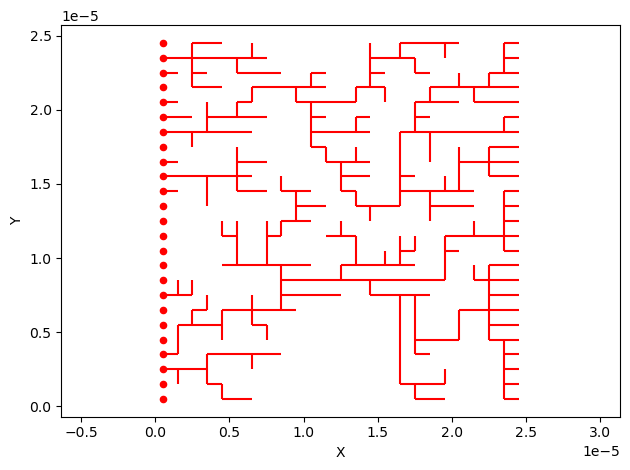

In [23]:
inv_pattern = ip['throat.invasion_sequence']<=3000
ax = op.visualization.plot_coordinates(network=pn, pores=Inlets, c='r', s=20)
ax = op.visualization.plot_connections(network=pn, throats=inv_pattern, c='r', linewidth=1.5 ,ax=ax)
#ax = op.visualization.plot_connections(network=pn, throats=~inv_pattern, c='b', ax=ax)

In [24]:
path_to_file = current_directory
op.io._vtk.project_to_vtk(pn.project, filename=path_to_file+'/2D_25x25_Hys/'+'/Cubic_25x25_Drainage')

# Relative Permeability for Drainage

In [25]:
def sat_occ_update(network, nwp, wp, ip, i):
    r"""
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    # Create masks for invaded pore/throats
    pore_mask = (ip['pore.invasion_sequence'] < i)
    throat_mask = (ip['throat.invasion_sequence'] < i )
    if np.any(throat_mask):
        nwp['throat.value_p0'] = np.max(ip['throat.invasion_pressure'][throat_mask])+value_p0        
        nwp['pore.value_p0'] = np.max(ip['throat.invasion_pressure'][throat_mask])+value_p0
    else:
        nwp['throat.value_p0']  = value_p0 # 8273709 # 101325.0
        nwp['pore.value_p0']  = value_p0
    # Calculates volumes for wetting phase (non-invaded volumes)
    wp_sat_p = np.sum(network['pore.volume'][~pore_mask])
    wp_sat_t = np.sum(network['throat.volume'][~throat_mask])
    wp_sat = wp_sat_p + wp_sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()

    # Calculateas the Saturation of the weatting phase
    sat = wp_sat/bulk

    # Update the phase occupancy
    nwp['pore.occupancy'] = pore_mask
    nwp['throat.occupancy'] = throat_mask
    wp['throat.occupancy'] = ~throat_mask
    wp['pore.occupancy'] = ~pore_mask
    # print('CO2 occupancy \n',nwp['pore.occupancy'])
    # print('water occupancy \n',wp['pore.occupancy'])
    return sat

In [26]:
def Rate_calc(network, phase, inlet, outlet, conductance):
    """
    Simulates stokes flow given the hydraulic conductance keyword 
    and returns the rate of inlet fluid flow.
    
    Parameters
    ----------
    network : network
    phase : phase
    inlet : array
        inlet pores
    outlet : array
        outlet pores
    conductance : str
        name of conductance model to use
    """
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    phase.update(St_p.soln)
    return val

In [27]:
CO2.add_model(propname='throat.viscosity',
              model=op.models.misc.linear,
              m=3.9625838546682686e-12,
              b=1.4797354840394226e-05,
              prop='throat.value_p0',
              regen_mode='deferred')
CO2.add_model(propname='pore.viscosity',
              model=op.models.misc.linear,
              m=3.9625838546682686e-12,
              b=1.4797354840394226e-05,
              prop='pore.value_p0',
              regen_mode='deferred')

In [28]:
model_mp_cond = op.models.physics.multiphase.conduit_conductance
CO2.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')
water.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')

In [29]:
User_count = 1000
start = 10
stop = 3000
step = 10
Swp = []
relperm_nwp = []
relperm_wp = []

In [30]:
for i in range(start, stop, step):
    CO2.regenerate_models()
    water.regenerate_models()
    
    sat= sat_occ_update(network=pn, nwp=CO2, wp=water, ip=ip, i=i) 
    
    Swp.append(sat)

    Rate_abs_nwp = Rate_calc(pn, CO2, Inlets, Outlets, 
                            conductance='throat.hydraulic_conductance')
    Rate_abs_wp = Rate_calc(pn, water, Inlets, Outlets, 
                           conductance='throat.hydraulic_conductance')
    Rate_enwp = Rate_calc(pn, CO2, Inlets, Outlets, 
                          conductance = 'throat.conduit_hydraulic_conductance')
    Rate_ewp = Rate_calc(pn, water, Inlets, Outlets, 
                         conductance = 'throat.conduit_hydraulic_conductance')
    relperm_nwp.append(Rate_enwp/Rate_abs_nwp)
    
    relperm_wp.append(Rate_ewp/Rate_abs_wp)

In [31]:
plt.figure(figsize=[6,5])
plt.plot(Swp, relperm_nwp, marker='*', markersize=5, label='Kr_nwp')
plt.plot(Swp, relperm_wp, marker='o',markersize=5,label='Kr_wp')
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.title('Relative Permeability in x direction')
plt.legend()
plt.savefig(f"2D_25x25_Hys/Krel_Drain_25x25_new_Alg.png")
plt.close()

# CO2 Permeability after Drainage

As relative permeability is the ratio of effective over absolute permeability, given the same boundary condition and viscosity, the geometrical parameters in

will cancel out. The remaining fraction includes flow rates as follows:

Where is the inlet flow rate of the phase (water/air) for a Stokes flow algorithm with multiphase conduit_conductance assigned as conduit hydraulic conductance model to account for the existence of the other phase. Whereas

is the inlet flow rate of the phase (water/air) for a Stokes flow algorithm with generic_hydraulic_conductance assigned as hydraulic conductance model for a single phase flow.

Note that
is a property of the porous material, not the fluid. However, here to cancel out viscosity in the fraction, the same phase must be used to calculate . Therefore, naming abs-phase was used here to indicate the flow rate from a single phase flow algorithm for the same phase that relative permeability is being calculated. Therefore, we only need to find the rate values for calculating the relative permeability. 

# Imbibition

In [32]:
Pinv_0 = Pinv
Tinv_0 = Tinv
P_trap = np.where(~Pinv)
T_trap = np.where(~Tinv)
New_P_inside = np.setdiff1d(P_inside,P_trap)
#print(New_P_inside)

In [33]:
nTinv = np.size(T_trap)
nPinv = np.size(P_trap)
print(nTinv,nPinv)

845 245


In [34]:
Max_seq1 = 5e3
ip_ad = {}
ip_ad['throat.invasion_pressure'] = np.zeros(pn.Nt, dtype=float)
ip_ad['pore.invasion_pressure'] = np.zeros(pn.Np, dtype=float)
ip_ad['throat.invasion_sequence'] = np.full(pn.Nt,Max_seq1,dtype=int)
ip_ad['pore.invasion_sequence'] = np.full(pn.Np,Max_seq1,dtype=int)
ip_ad['throat.invasion_sequence'][T_trap] = np.zeros(nTinv,dtype=int)
ip_ad['pore.invasion_sequence'][P_trap] = np.zeros(nPinv,dtype=int)

In [35]:
Pinv_ad = np.zeros(pn.Np, dtype=bool)  # Pre-allocate array for storing pore invasion state
Tinv_ad= np.zeros(pn.Nt, dtype=bool)  # Pre-allocate array for storing throat invasion state

In [36]:
Pinv_ad[Inlets] = True
# list of the throats linked to the Inlet pores that are candidates to be invided
q_ad = [(water['throat.entry_pressure'][i], i ) for i in Ts1]
#Sort for the minimum  Capillary pressure of the throats that candidates to be invaded
hq.heapify(q_ad)
#print(q_ad) 

In [37]:
print(water['throat.entry_pressure'].max())
print(water['throat.entry_pressure'].min())

-355720.5091724178
-1207125.273034352


In [38]:
# Here we set the entry pressure curve
max = 1* water['throat.entry_pressure'].max()
min = 0.35* water['throat.entry_pressure'].min()
steps = 30
x = np.linspace(0,1,steps)
print(max, min)
Global_T_entry_p_ad = min * (max/min) ** x  
#logspace(np.log10(low),np.log10(hi), Global_T_entry_p)
print(Global_T_entry_p_ad)

-355720.5091724178 -422493.8455620232
[-422493.84556202 -419995.00852002 -417510.95083309 -415041.58508884
 -412586.82439188 -410146.58236075 -407720.7731249  -405309.31132165
 -402912.11209322 -400529.09108368 -398160.16443608 -395805.24878939
 -393464.26127564 -391137.11951699 -388823.7416228  -386524.0461868
 -384237.95228417 -381965.37946873 -379706.24777012 -377460.47769092
 -375227.99020393 -373008.70674934 -370802.549232   -368609.44001864
 -366429.30193514 -364262.05826386 -362107.63274086 -359965.9495533
 -357836.93333673 -355720.50917242]


In [39]:
counter1 = 0
counter_press_ad = 0
ip_ad['pore.invasion_sequence'][Pinv_ad] = counter1

In [40]:
# Loop over pressures
for pressure1 in Global_T_entry_p_ad:
    try: 
        counter_press_ad += 1
        int_pore_queue = list(New_P_inside)
        ip_ad['pore.invasion_sequence'][Inlets] = 0
        pressure_check1 = np.any(water['throat.entry_pressure'][i] <= pressure1 for i in Ts1)
        #print('At pressure',pressure,'which inlet throats',pressure_check1)
      
        if not pressure_check1:
             #print('Not throat to be invaded at pressure',pressure1)
             continue

        while len(int_pore_queue) > 0 :
            try:
                pore_index = hq.heappop(int_pore_queue)
                #print('Pore', pore_index)
                # Find neighboring throats of the current pore
                neighbor_throats = incidence_m[pore_index].nonzero()[1]
                #print('Neigh_throats',neighbor_throats)
             
                can_invade1 = [(water['throat.entry_pressure'][i],i) 
                              for i in neighbor_throats 
                              if water['throat.entry_pressure'][i]<=pressure1 and Pinv_ad[pore_index]]
                #print(can_invade1)
                if not can_invade1:
                    #print('O poro', pore_index,'nao tem nenhuma garganta para invadir',can_invade1)
                    continue

                # print('throats can be invaded',can_invade1)
                
                throat_indices = [thr_indx for pres, thr_indx in can_invade1]
                                
                valid_paths = bfs_from_initial_pore(initial_pore = pore_index,
                                                    throats = throat_indices,
                                                    conns = pn.conns,
                                                    incidence_matrix = incidence_m,
                                                    outlet_pores = Outlets,
                                                    throat_mask = Tinv,
                                                    pore_mask = Pinv)
                
                if not valid_paths:
                    #print('O poro', pore_index,'nao tem nenhum caminho para invadir',can_invade)
                    continue
                    
                for i, path in enumerate(valid_paths, start=1):
                    if not path:
                        #print(f'Path {i} is empty.')
                        continue

                    filtered_elements = []
                    previous_passed = True

                    for element in path:
                        if previous_passed and water['throat.entry_pressure'][element] <= pressure1:
                            filtered_elements.append(element)
                            previous_passed = True
                        else:
                            previous_passed = False
                            break

                    if not filtered_elements:
                        #print('Nao tem elements in path', path,'elementos',filtered_elements)
                        continue

                    Tinv_ad[filtered_elements] = True
                    # Update the throats that are still available
                    Tinv = Tinv & ~Tinv_ad
                    ip_ad['throat.invasion_pressure'][filtered_elements] = pressure1
                    pores = pn.conns[filtered_elements]
                    Pinv_ad[pores] = True
                    Pinv = Pinv & ~Pinv_ad
                    ip_ad['pore.invasion_pressure'][pores] = pressure1                           
                    Tinv = Tinv & ~Tinv_ad  
                    counter1 += 1 
                    ip_ad['throat.invasion_sequence'][filtered_elements] = counter1
                    ip_ad['pore.invasion_sequence'][pores] = counter1                   

            except Exception as e:
                #print(f"Error in invading neighboring throats for pore {pore_index} at pressure {pressure1}: {e}")
                raise
                
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left'), c='r', s=40)
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('right'), c='yellow', s=40, ax=ax)
        ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left', mode='not'), c='blue', s=20, ax=ax)
        ax = op.visualization.plot_connections(network=pn, throats=pn.throats(), c='blue', linewidth=0.5, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv_0, s=20, c='red', ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv_0, c='red', linewidth=1, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv_ad, s=40 ,c='blue',ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv_ad , c='blue',linewidth=2, ax=ax)
        plt.savefig(f"2D_25x25_Hys/Imbib_25x25_{str(counter_press_ad).zfill(3)}.png")
        plt.close()
   
    except Exception as e:
         print(f"An error occurred at pressure {pressure1}: {e}")
         raise  # Reraise the error for debugging purposes if needed


In [41]:
#print(ip_ad['throat.invasion_sequence'])

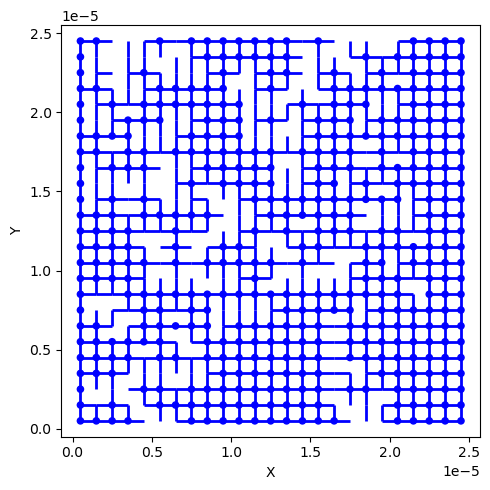

In [42]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  size_by=(ip_ad["pore.invasion_sequence"]<900), #10000),
                                  color='blue', 
                                  markersize=20)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  size_by=(ip_ad["throat.invasion_sequence"]<900),#10000),
                                  color='blue', 
                                  linewidth=2)

plt.savefig(f"2D_25x25_Hys/Imbibi_25x25.png")

# Relative Permeability for Imbibition

In [43]:
# print(ip_ad['throat.invasion_pressure'])

In [44]:
Snwparr1 = []
Swp1 = []
relperm_nwp1 = []
relperm_wp1 = []

In [45]:
def sat_occ_update_imb(network, nwp, wp, ip_ad, i):
    r"""
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    # Create masks for invaded pore/throats
    pore_mask = (ip_ad['pore.invasion_sequence'] <= i)
    throat_mask = (ip_ad['throat.invasion_sequence'] <= i )
    
    if np.any(throat_mask):
        nwp['throat.value_p0'] = np.max(ip['throat.invasion_pressure'][throat_mask])+value_p0        
        nwp['pore.value_p0'] = np.max(ip['throat.invasion_pressure'][throat_mask])+value_p0
    else:
        nwp['throat.value_p0']  = value_p0 # 8273709 # 101325.0
        nwp['pore.value_p0']  = value_p0
        
    # Calculates volumes for wetting phase (non-invaded volumes)
    wp_sat_p = np.sum(network['pore.volume'][pore_mask])
    wp_sat_t = np.sum(network['throat.volume'][throat_mask])
    wp_sat = wp_sat_p + wp_sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()

    # Calculateas the Saturation of the weatting phase
    sat = wp_sat/bulk

    # Update the phase occupancy
    nwp['pore.occupancy'] = ~pore_mask
    nwp['throat.occupancy'] = ~throat_mask
    wp['throat.occupancy'] = throat_mask
    wp['pore.occupancy'] = pore_mask
    # print('CO2 occupancy \n',nwp['pore.occupancy'])
    # print('water occupancy \n',wp['pore.occupancy'])
    return sat

In [46]:
def Rate_calc1(network, phase, inlet, outlet, conductance):
    """
    Simulates stokes flow given the hydraulic conductance keyword 
    and returns the rate of inlet fluid flow.
    
    Parameters
    ----------
    network : network
    phase : phase
    inlet : array
        inlet pores
    outlet : array
        outlet pores
    conductance : str
        name of conductance model to use
    """
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    phase.update(St_p.soln)
    return val

In [47]:
start = 0
stop = 150
step = 1

In [48]:
for i in range(start, stop, step):
    CO2.regenerate_models()
    water.regenerate_models()
    
    sat = sat_occ_update_imb(network=pn, nwp=CO2, wp=water, ip_ad=ip_ad, i=i)
    Swp1.append(sat) 

    Rate_abs_nwp1 = Rate_calc1(pn, CO2, Inlets, Outlets, 
                            conductance='throat.hydraulic_conductance')
    Rate_abs_wp1 = Rate_calc1(pn, water, Inlets, Outlets, 
                           conductance='throat.hydraulic_conductance')
    Rate_ewp1 = Rate_calc1(pn, water, Inlets, Outlets, 
                           conductance = 'throat.conduit_hydraulic_conductance')
    Rate_enwp1 = Rate_calc1(pn, CO2, Inlets, Outlets, 
                            conductance = 'throat.conduit_hydraulic_conductance')
    relperm_wp1.append(Rate_ewp1/Rate_abs_wp1)
    relperm_nwp1.append(Rate_enwp1/Rate_abs_nwp1)

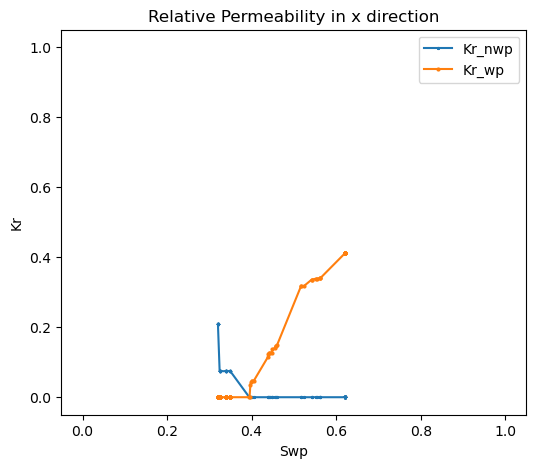

In [49]:
plt.figure(figsize=[6,5])
plt.plot(Swp1, relperm_nwp1, marker='*', markersize=2, label='Kr_nwp')
plt.plot(Swp1, relperm_wp1, marker='o',markersize=2,label='Kr_wp')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.title('Relative Permeability in x direction')
plt.legend()
plt.savefig(f"2D_25x25_Hys/Krel_Imbib_25x25.png")
#plt.close()


In [50]:
path_to_file = current_directory
op.io._vtk.project_to_vtk(pn.project, filename=path_to_file+'/2D_25x25_Hys/'+'/Cubic_25x25_Imbibition')